#**Food Delivery Time Prediction**

This dataset is designed for predicting food delivery times based on various influencing factors such as distance, weather, traffic conditions, and time of day. It offers a practical and engaging challenge for machine learning practitioners, especially those interested in logistics and operations research.


###**Key Features:**

Order_ID: Unique identifier for each order.

Distance_km: The delivery distance in kilometers.

Weather: Weather conditions during the delivery, including Clear, Rainy, Snowy, Foggy, and Windy.

Traffic_Level: Traffic conditions categorized as Low, Medium, or High.

Time_of_Day: The time when the delivery took place, categorized as Morning, Afternoon, Evening, or Night.

Vehicle_Type: Type of vehicle used for delivery, including Bike, Scooter, and Car.

Preparation_Time_min: The time required to prepare the order, measured in minutes.

Courier_Experience_yrs: Experience of the courier in years.

Delivery_Time_min: The total delivery time in minutes (target variable).

### **Importing Libraries**

In [ ]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

### **Load Data**

In [ ]:
data = pd.read_csv('Food.csv')
data

,Order_ID,Distance_km,Weather,Traffic_Level,Time_of_Day,Vehicle_Type,Preparation_Time_min,Courier_Experience_yrs,Delivery_Time_min
0,522,7.93,Windy,Low,Afternoon,Scooter,12,1.0,43
1,738,16.42,Clear,Medium,Evening,Bike,20,2.0,84
2,741,9.52,Foggy,Low,Night,Scooter,28,1.0,59
3,661,7.44,Rainy,Medium,Afternoon,Scooter,5,1.0,37
4,412,19.03,Clear,Low,Morning,Bike,16,5.0,68
...,...,...,...,...,...,...,...,...,...
995,107,8.50,Clear,High,Evening,Car,13,3.0,54
996,271,16.28,Rainy,Low,Morning,Scooter,8,9.0,71
997,861,15.62,Snowy,High,Evening,Scooter,26,2.0,81
998,436,14.17,Clear,Low,Afternoon,Bike,8,0.0,55


### **Basic Checks**

In [ ]:
data.shape

(1000, 9)

In [ ]:
data.head()

,Order_ID,Distance_km,Weather,Traffic_Level,Time_of_Day,Vehicle_Type,Preparation_Time_min,Courier_Experience_yrs,Delivery_Time_min
0,522,7.93,Windy,Low,Afternoon,Scooter,12,1.0,43
1,738,16.42,Clear,Medium,Evening,Bike,20,2.0,84
2,741,9.52,Foggy,Low,Night,Scooter,28,1.0,59
3,661,7.44,Rainy,Medium,Afternoon,Scooter,5,1.0,37
4,412,19.03,Clear,Low,Morning,Bike,16,5.0,68


In [ ]:
data.tail()

,Order_ID,Distance_km,Weather,Traffic_Level,Time_of_Day,Vehicle_Type,Preparation_Time_min,Courier_Experience_yrs,Delivery_Time_min
995,107,8.50,Clear,High,Evening,Car,13,3.0,54
996,271,16.28,Rainy,Low,Morning,Scooter,8,9.0,71
997,861,15.62,Snowy,High,Evening,Scooter,26,2.0,81
998,436,14.17,Clear,Low,Afternoon,Bike,8,0.0,55
999,103,6.63,Foggy,Low,Night,Scooter,24,3.0,58


In [ ]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 9 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Order_ID                1000 non-null   int64  
 1   Distance_km             1000 non-null   float64
 2   Weather                 970 non-null    object 
 3   Traffic_Level           970 non-null    object 
 4   Time_of_Day             970 non-null    object 
 5   Vehicle_Type            1000 non-null   object 
 6   Preparation_Time_min    1000 non-null   int64  
 7   Courier_Experience_yrs  970 non-null    float64
 8   Delivery_Time_min       1000 non-null   int64  
dtypes: float64(2), int64(3), object(4)
memory usage: 70.4+ KB


In [ ]:
#drop customer Id columns
data.drop(columns=['Order_ID'], inplace=True)

In [ ]:
data.describe()

,Distance_km,Preparation_Time_min,Courier_Experience_yrs,Delivery_Time_min
count,1000.000000,1000.000000,970.000000,1000.000000
mean,10.059970,16.982000,4.579381,56.732000
std,5.696656,7.204553,2.914394,22.070915
min,0.590000,5.000000,0.000000,8.000000
25%,5.105000,11.000000,2.000000,41.000000
50%,10.190000,17.000000,5.000000,55.500000
75%,15.017500,23.000000,7.000000,71.000000
max,19.990000,29.000000,9.000000,153.000000


In [ ]:
num_col=data.select_dtypes(include=['int64','float64'])
num_col

,Distance_km,Preparation_Time_min,Courier_Experience_yrs,Delivery_Time_min
0,7.93,12,1.0,43
1,16.42,20,2.0,84
2,9.52,28,1.0,59
3,7.44,5,1.0,37
4,19.03,16,5.0,68
...,...,...,...,...
995,8.50,13,3.0,54
996,16.28,8,9.0,71
997,15.62,26,2.0,81
998,14.17,8,0.0,55


In [ ]:
cat_col=data.select_dtypes(include=['object'])
cat_col

,Weather,Traffic_Level,Time_of_Day,Vehicle_Type
0,Windy,Low,Afternoon,Scooter
1,Clear,Medium,Evening,Bike
2,Foggy,Low,Night,Scooter
3,Rainy,Medium,Afternoon,Scooter
4,Clear,Low,Morning,Bike
...,...,...,...,...
995,Clear,High,Evening,Car
996,Rainy,Low,Morning,Scooter
997,Snowy,High,Evening,Scooter
998,Clear,Low,Afternoon,Bike


### **Data Cleaning**

In [ ]:
data.isnull().sum()

,0
Distance_km,0
Weather,30
Traffic_Level,30
Time_of_Day,30
Vehicle_Type,0
Preparation_Time_min,0
Courier_Experience_yrs,30
Delivery_Time_min,0


We have missing values in Weather, Traffic volume, Time of Day, Courier experiencs yrs. need to replace with mean, median and mode.

In [ ]:
data.duplicated().sum()

np.int64(0)

**Weather**

In [ ]:
# check data type of column
data.loc[:,'Weather'].dtype

dtype('O')

In [ ]:
data.loc[:,'Weather'].mode()[0]

'Clear'

In [ ]:
# using fillna will replace missing values with mode
data.loc[:,'Weather']=data.loc[:,'Weather'].fillna(data.loc[:,'Weather'].mode()[0])

In [ ]:
data.loc[:,'Weather'].isnull().sum()

np.int64(0)

**Traffic Level**

In [ ]:
# check data type of column
data.loc[:,'Traffic_Level'].dtype

dtype('O')

In [ ]:
data.loc[:,'Traffic_Level'].mode()[0]

'Medium'

In [ ]:
# using fillna will replace missing values with mode
data.loc[:,'Traffic_Level']=data.loc[:,'Traffic_Level'].fillna(data.loc[:,'Traffic_Level'].mode()[0])

In [ ]:
data.loc[:,'Traffic_Level'].isnull().sum()

np.int64(0)

**Time of Day**

In [ ]:
# check data type of column
data.loc[:,'Time_of_Day'].dtype

dtype('O')

In [ ]:
data.loc[:,'Time_of_Day'].mode()[0]

'Morning'

In [ ]:
# using fillna will replace missing values with mode
data.loc[:,'Time_of_Day']=data.loc[:,'Time_of_Day'].fillna(data.loc[:,'Time_of_Day'].mode()[0])

In [ ]:
data.loc[:,'Time_of_Day'].isnull().sum()

np.int64(0)

**Courier Experience yrs**

In [ ]:
# check data type
data.loc[:,'Courier_Experience_yrs'].dtype

dtype('float64')

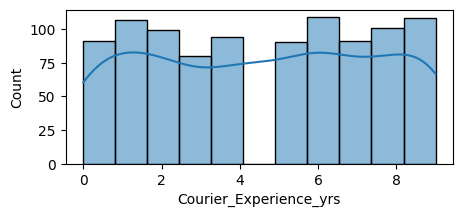

In [ ]:

# If numeric check the distribution
# histogram
plt.figure(figsize=(5,2))
sns.histplot(data,x='Courier_Experience_yrs',kde=True)
plt.show()

In [ ]:
data.loc[:,'Courier_Experience_yrs'].skew()

np.float64(-0.029086829121382836)

Since skewness is within [-0.5,0.5] the distribution of Courier_Experience_yrs is normal. We have to replace missing value with mean.

In [ ]:
# find mean
data.loc[:,'Courier_Experience_yrs'].mean()

np.float64(4.579381443298969)

In [ ]:
# replace with mean
data.loc[:,'Courier_Experience_yrs'] = data.loc[:,'Courier_Experience_yrs'].fillna(data.loc[:,'Courier_Experience_yrs'].mean())

In [ ]:
data.loc[:,'Courier_Experience_yrs'].isnull().sum()

np.int64(0)

In [ ]:
data.isnull().sum()

,0
Distance_km,0
Weather,0
Traffic_Level,0
Time_of_Day,0
Vehicle_Type,0
Preparation_Time_min,0
Courier_Experience_yrs,0
Delivery_Time_min,0


In [ ]:
data

,Distance_km,Weather,Traffic_Level,Time_of_Day,Vehicle_Type,Preparation_Time_min,Courier_Experience_yrs,Delivery_Time_min
0,7.93,Windy,Low,Afternoon,Scooter,12,1.0,43
1,16.42,Clear,Medium,Evening,Bike,20,2.0,84
2,9.52,Foggy,Low,Night,Scooter,28,1.0,59
3,7.44,Rainy,Medium,Afternoon,Scooter,5,1.0,37
4,19.03,Clear,Low,Morning,Bike,16,5.0,68
...,...,...,...,...,...,...,...,...
995,8.50,Clear,High,Evening,Car,13,3.0,54
996,16.28,Rainy,Low,Morning,Scooter,8,9.0,71
997,15.62,Snowy,High,Evening,Scooter,26,2.0,81
998,14.17,Clear,Low,Afternoon,Bike,8,0.0,55


### **Exploratory Data Analysis**

### **Univariate Analysis**

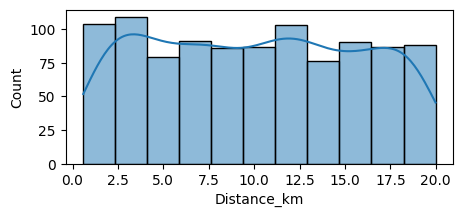

In [ ]:
#hist
plt.figure(figsize=(5,2))
sns.histplot(data,x='Distance_km',kde=True)
plt.show()

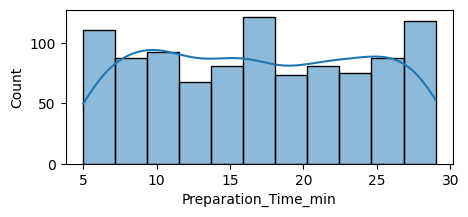

In [ ]:
plt.figure(figsize=(5,2))
sns.histplot(data,x='Preparation_Time_min',kde=True)
plt.show()

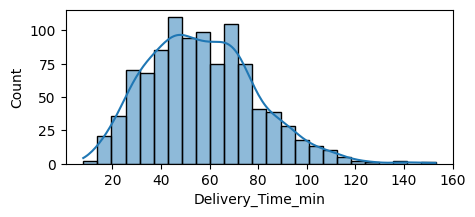

In [ ]:
plt.figure(figsize=(5,2))
sns.histplot(data,x='Delivery_Time_min',kde=True)
plt.show()


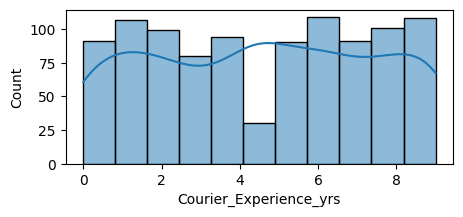

In [ ]:
plt.figure(figsize=(5,2))
sns.histplot(data,x='Courier_Experience_yrs',kde=True)
plt.show()


In [ ]:
data

,Distance_km,Weather,Traffic_Level,Time_of_Day,Vehicle_Type,Preparation_Time_min,Courier_Experience_yrs,Delivery_Time_min
0,7.93,Windy,Low,Afternoon,Scooter,12,1.0,43
1,16.42,Clear,Medium,Evening,Bike,20,2.0,84
2,9.52,Foggy,Low,Night,Scooter,28,1.0,59
3,7.44,Rainy,Medium,Afternoon,Scooter,5,1.0,37
4,19.03,Clear,Low,Morning,Bike,16,5.0,68
...,...,...,...,...,...,...,...,...
995,8.50,Clear,High,Evening,Car,13,3.0,54
996,16.28,Rainy,Low,Morning,Scooter,8,9.0,71
997,15.62,Snowy,High,Evening,Scooter,26,2.0,81
998,14.17,Clear,Low,Afternoon,Bike,8,0.0,55


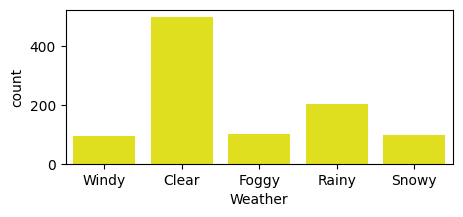

In [ ]:
#count #weather
plt.figure(figsize=(5,2))
sns.countplot(data,x='Weather',color='Yellow')
plt.show()

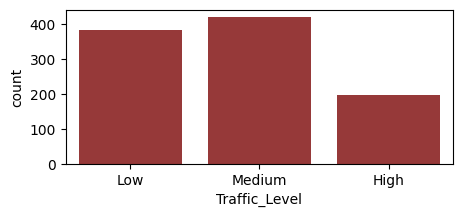

In [ ]:
#Traffic level
plt.figure(figsize=(5,2))
sns.countplot(data,x='Traffic_Level',color='brown')
plt.show()

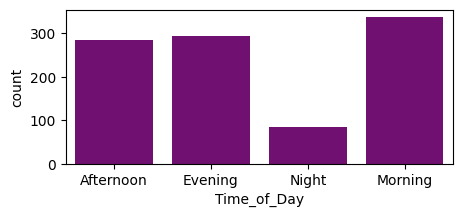

In [ ]:
#Time of day
plt.figure(figsize=(5,2))
sns.countplot(data,x='Time_of_Day',color='purple')
plt.show()

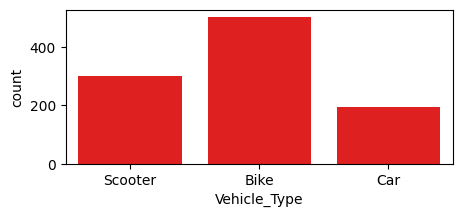

In [ ]:
#vehicle type
plt.figure(figsize=(5,2))
sns.countplot(data,x='Vehicle_Type',color='red')
plt.show()

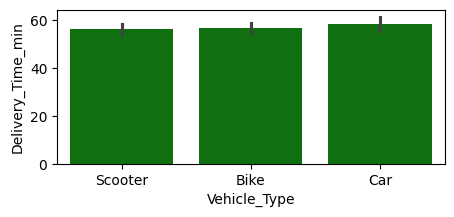

In [ ]:
#barplot
# vehicle vs delivery time min
plt.figure(figsize=(5,2))
sns.barplot(data,x='Vehicle_Type',y='Delivery_Time_min',color='green')
plt.show()

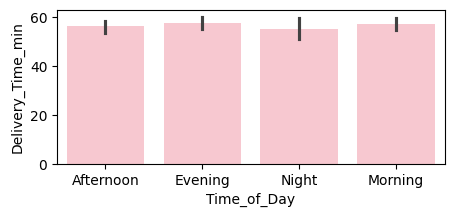

In [ ]:
#Time of the day vs delivery time min
plt.figure(figsize=(5,2))
sns.barplot(data,x='Time_of_Day',y='Delivery_Time_min',color='pink')
plt.show()

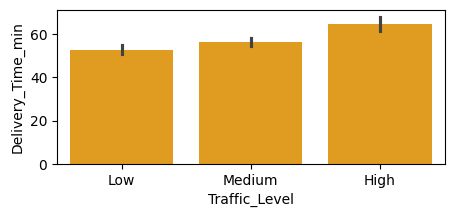

In [ ]:
#Traffic level vs delivery time min
plt.figure(figsize=(5,2))
sns.barplot(data,x='Traffic_Level',y='Delivery_Time_min',color='orange')
plt.show()

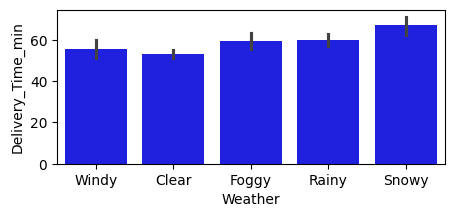

In [ ]:
#Traffic level vs delivery time min
plt.figure(figsize=(5,2))
sns.barplot(data,x='Weather',y='Delivery_Time_min',color='blue')
plt.show()

### **Bivariate**

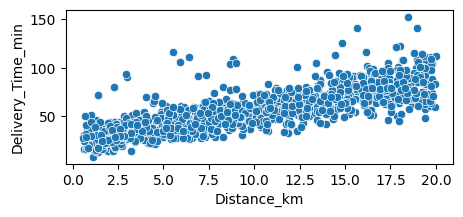

In [ ]:
#scatter
plt.figure(figsize=(5,2))
sns.scatterplot(data,x='Distance_km',y='Delivery_Time_min')
plt.show()

In [ ]:
data

,Distance_km,Weather,Traffic_Level,Time_of_Day,Vehicle_Type,Preparation_Time_min,Courier_Experience_yrs,Delivery_Time_min
0,7.93,Windy,Low,Afternoon,Scooter,12,1.0,43
1,16.42,Clear,Medium,Evening,Bike,20,2.0,84
2,9.52,Foggy,Low,Night,Scooter,28,1.0,59
3,7.44,Rainy,Medium,Afternoon,Scooter,5,1.0,37
4,19.03,Clear,Low,Morning,Bike,16,5.0,68
...,...,...,...,...,...,...,...,...
995,8.50,Clear,High,Evening,Car,13,3.0,54
996,16.28,Rainy,Low,Morning,Scooter,8,9.0,71
997,15.62,Snowy,High,Evening,Scooter,26,2.0,81
998,14.17,Clear,Low,Afternoon,Bike,8,0.0,55


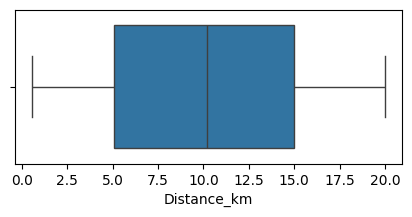

In [ ]:
#boxplot
plt.figure(figsize=(5,2))
sns.boxplot(data,x='Distance_km')
plt.show()

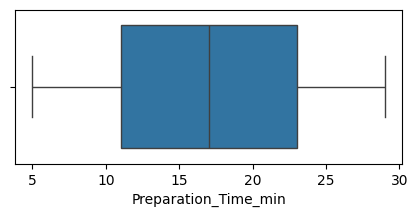

In [ ]:
#Preparation_Time_min
plt.figure(figsize=(5,2))
sns.boxplot(data,x='Preparation_Time_min')
plt.show()

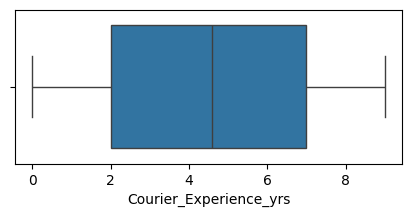

In [ ]:
#Courier_Experience_yrs
plt.figure(figsize=(5,2))
sns.boxplot(data,x='Courier_Experience_yrs')
plt.show()

### **Multivariate**

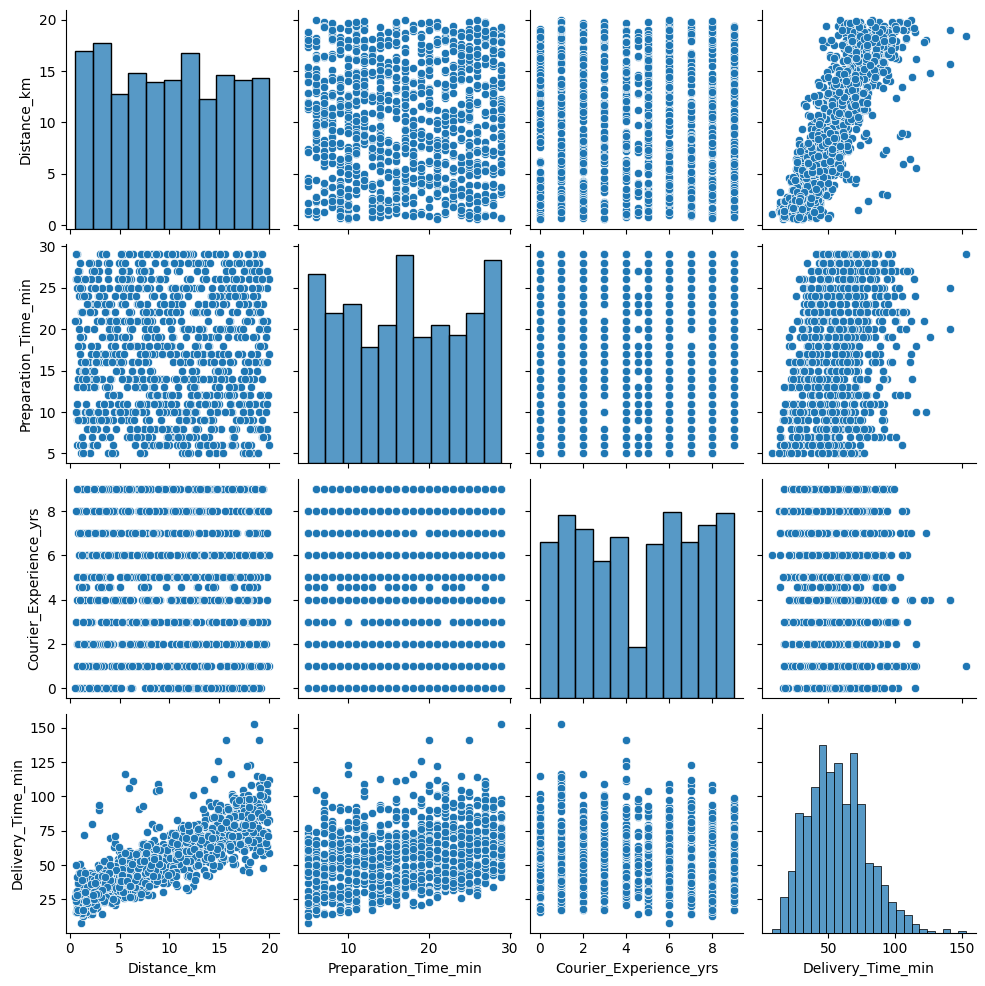

In [ ]:
#pairplot
sns.pairplot(data)

In [ ]:
corr = num_col.corr()
corr

,Distance_km,Preparation_Time_min,Courier_Experience_yrs,Delivery_Time_min
Distance_km,1.000000,-0.009037,-0.007842,0.780998
Preparation_Time_min,-0.009037,1.000000,-0.030830,0.307350
Courier_Experience_yrs,-0.007842,-0.030830,1.000000,-0.090433
Delivery_Time_min,0.780998,0.307350,-0.090433,1.000000


<Axes: >

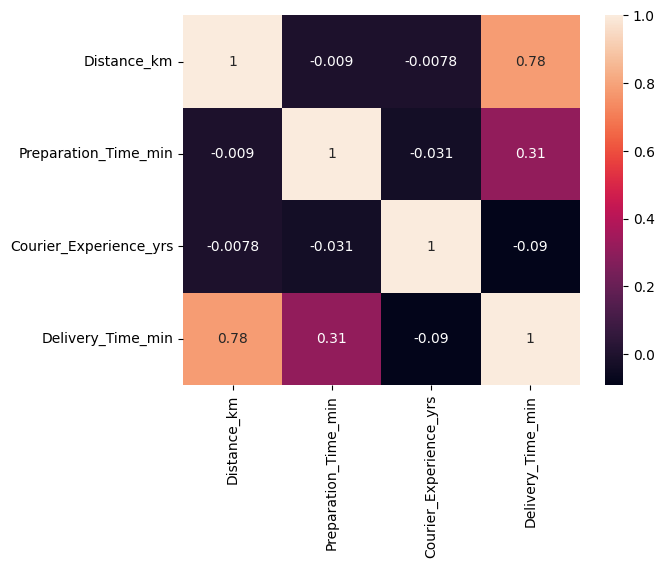

In [ ]:
#Heatmap
sns.heatmap(corr,annot=True)


### **Handling Outliers**


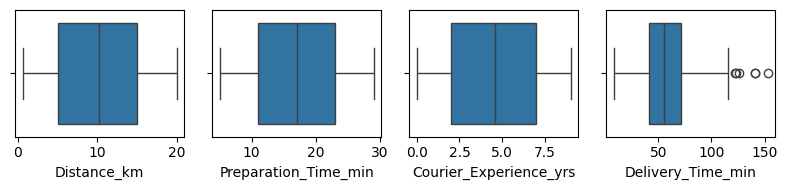

In [ ]:
fig,ax=plt.subplots(1,4,figsize=(8,2))
sns.boxplot(data,x='Distance_km',ax=ax[0])
sns.boxplot(data,x='Preparation_Time_min',ax=ax[1])
sns.boxplot(data,x='Courier_Experience_yrs',ax=ax[2])
sns.boxplot(data,x='Delivery_Time_min',ax=ax[3])
plt.tight_layout()

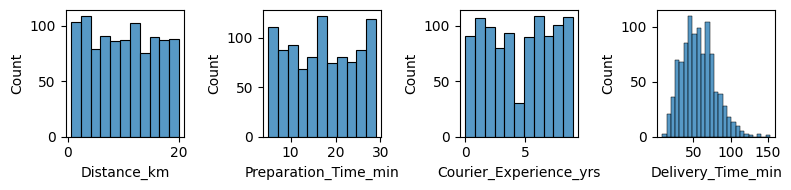

In [ ]:
fig,ax=plt.subplots(1,4,figsize=(8,2))
sns.histplot(data,x='Distance_km',ax=ax[0])
sns.histplot(data,x='Preparation_Time_min',ax=ax[1])
sns.histplot(data,x='Courier_Experience_yrs',ax=ax[2])
sns.histplot(data,x='Delivery_Time_min',ax=ax[3])
plt.tight_layout()

In [ ]:
df = ['Distance_km','Preparation_Time_min','Courier_Experience_yrs','Delivery_Time_min']
for x in df:
  print(x,'-->',data[x].skew())
  print()

Distance_km --> 0.038840474919290116

Preparation_Time_min --> 0.030008161330597263

Courier_Experience_yrs --> -0.029531827085890448

Delivery_Time_min --> 0.3387528092589373



In [ ]:
mean_val = data.loc[:,'Delivery_Time_min'].mean()
std_val = data.loc[:,'Delivery_Time_min'].std()
lower_limit = mean_val - 3* std_val
upper_limit = mean_val + 3* std_val

In [ ]:
# filter values greater than upper limit
data[data.loc[:,'Delivery_Time_min']>upper_limit]

,Distance_km,Weather,Traffic_Level,Time_of_Day,Vehicle_Type,Preparation_Time_min,Courier_Experience_yrs,Delivery_Time_min
29,18.05,Clear,Medium,Evening,Scooter,10,7.0,123
127,18.97,Clear,Low,Evening,Car,25,4.0,141
379,18.46,Clear,Medium,Morning,Scooter,29,1.0,153
452,15.64,Rainy,Low,Morning,Bike,20,4.0,141
784,14.83,Rainy,Low,Morning,Car,19,4.0,126


In [ ]:
# filter values less than lower limit
data[data.loc[:,'Delivery_Time_min']<lower_limit]

,Distance_km,Weather,Traffic_Level,Time_of_Day,Vehicle_Type,Preparation_Time_min,Courier_Experience_yrs,Delivery_Time_min


In [ ]:
len(data[(data.loc[:,'Delivery_Time_min']>upper_limit)|(data.loc[:,'Delivery_Time_min']<lower_limit)])/len(data)*100

0.5

In [ ]:
# replace with mean
data.loc[data.loc[:,'Delivery_Time_min']>upper_limit,'Delivery_Time_min']=data.loc[:,'Delivery_Time_min'].mean()

/tmp/ipykernel_13634/403975814.py:2: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '56.732' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  data.loc[data.loc[:,'Delivery_Time_min']>upper_limit,'Delivery_Time_min']=data.loc[:,'Delivery_Time_min'].mean()


### **Encoding**

In [ ]:
data

,Distance_km,Weather,Traffic_Level,Time_of_Day,Vehicle_Type,Preparation_Time_min,Courier_Experience_yrs,Delivery_Time_min
0,7.93,Windy,Low,Afternoon,Scooter,12,1.0,43.0
1,16.42,Clear,Medium,Evening,Bike,20,2.0,84.0
2,9.52,Foggy,Low,Night,Scooter,28,1.0,59.0
3,7.44,Rainy,Medium,Afternoon,Scooter,5,1.0,37.0
4,19.03,Clear,Low,Morning,Bike,16,5.0,68.0
...,...,...,...,...,...,...,...,...
995,8.50,Clear,High,Evening,Car,13,3.0,54.0
996,16.28,Rainy,Low,Morning,Scooter,8,9.0,71.0
997,15.62,Snowy,High,Evening,Scooter,26,2.0,81.0
998,14.17,Clear,Low,Afternoon,Bike,8,0.0,55.0


In [ ]:
print(data['Vehicle_Type'].unique())
print(data['Weather'].unique())
print(data['Traffic_Level'].unique())
print(data['Time_of_Day'].unique())

['Scooter' 'Bike' 'Car']
['Windy' 'Clear' 'Foggy' 'Rainy' 'Snowy']
['Low' 'Medium' 'High']
['Afternoon' 'Evening' 'Night' 'Morning']


In [ ]:
#Ordinal Encoding
priority_mapping = {
    'Low': 0,
    'Medium': 1,
    'High': 2
}

data['Traffic_Level'] = data['Traffic_Level'].map(priority_mapping)

In [ ]:
#Target Encoder
data.loc[:,'VEHICLE_Type']=data.loc[:,'Vehicle_Type'].map({'Scooter':0,'Bike':1,'Car':2})

In [ ]:
data.drop(columns='Vehicle_Type',inplace=True)

In [ ]:
#Target Encoder
data.loc[:,'WEATHER']=data.loc[:,'Weather'].map({'Clear':0,'Windy':1,'Foggy':2,'Rainy':3,'Snowy':4})

In [ ]:
data.drop(columns='Weather',inplace=True)

In [ ]:
#Target Encoder
data.loc[:,'TIME_of_Day']=data.loc[:,'Time_of_Day'].map({'Night':0,'Morning':2,'Afternoon':1,'Evening':3})

In [ ]:
data.drop(columns='Time_of_Day',inplace=True)

In [ ]:
data

,Distance_km,Traffic_Level,Preparation_Time_min,Courier_Experience_yrs,Delivery_Time_min,VEHICLE_Type,WEATHER,TIME_of_Day
0,7.93,0,12,1.0,43.0,0,1,1
1,16.42,1,20,2.0,84.0,1,0,3
2,9.52,0,28,1.0,59.0,0,2,0
3,7.44,1,5,1.0,37.0,0,3,1
4,19.03,0,16,5.0,68.0,1,0,2
...,...,...,...,...,...,...,...,...
995,8.50,2,13,3.0,54.0,2,0,3
996,16.28,0,8,9.0,71.0,0,3,2
997,15.62,2,26,2.0,81.0,0,4,3
998,14.17,0,8,0.0,55.0,1,0,1


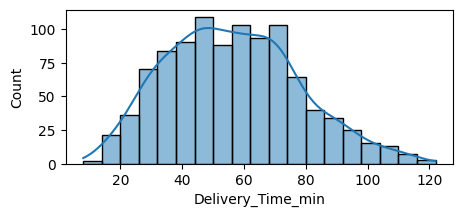

In [ ]:
# Delivery Time min
plt.figure(figsize=(5,2))
sns.histplot(data,x='Delivery_Time_min',kde=True)
plt.show()

### **Split data for x and y**

In [ ]:
x = data.drop(columns='Delivery_Time_min')
y= data['Delivery_Time_min']

### **Split data for training as well testing**

In [ ]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.2)

### **Linear Regression**

In [ ]:
# import the model
from sklearn.linear_model import LinearRegression
# initialise the model
model = LinearRegression()
# train model : x_train,y_train
model.fit(x_train,y_train)

LinearRegression()

In [ ]:
# make predictions
y_pred = model.predict(x_test)

In [ ]:
# Slope
print(model.coef_)

[ 2.92917391  6.49589861  0.93981111 -0.64469122  0.85710742  2.09790021
  0.26863254]


In [ ]:
# intercept
print(model.intercept_)

4.861527677817932


### **Evaluate the Linear Regression**

In [ ]:
from sklearn.metrics import mean_squared_error,mean_absolute_error,mean_absolute_percentage_error,r2_score

In [ ]:
# evaluate the model
print('mse: ',mean_squared_error(y_test,y_pred))
print('mae: ',mean_absolute_error(y_test,y_pred))
print('rmse: ',np.sqrt(mean_squared_error(y_test,y_pred)))
print('mape: ',mean_absolute_percentage_error(y_test,y_pred))
print('r2: ',r2_score(y_test,y_pred))

mse:  67.13862381858857
mae:  5.781729034115793
rmse:  8.193816193849393
mape:  0.1059836330616305
r2:  0.8346326766954026


In [ ]:
n= x_test.shape[0]
n # number of rows

200

In [ ]:
p= x_test.shape[1]
p #number of features

7

In [ ]:
r2= r2_score(y_test,y_pred)
r2

0.8346326766954026

In [ ]:
adj = 1 - (1-r2)*(n-1)/(n-p-1)
adj

0.8286036596999226

### **KNN Regressor**

In [ ]:
from sklearn.neighbors import KNeighborsRegressor
model = KNeighborsRegressor(n_neighbors=10)
model.fit(x_train,y_train)
y_pred = model.predict(x_test)

In [ ]:
# evaluate the model
print('mse: ',mean_squared_error(y_test,y_pred))
print('mae: ',mean_absolute_error(y_test,y_pred))
print('rmse: ',np.sqrt(mean_squared_error(y_test,y_pred)))
print('mape: ',mean_absolute_percentage_error(y_test,y_pred))
print('r2: ',r2_score(y_test,y_pred))

mse:  81.9877349616
mae:  6.94634
rmse:  9.05470788935789
mape:  0.1356738438636686
r2:  0.798058233796375


### **How to find best K value**

In [ ]:
error=[]
for k in range(2,11):
  model = KNeighborsRegressor(n_neighbors=k)
  model.fit(x_train,y_train)
  y_pred = model.predict(x_test)
  rmse = np.sqrt(mean_squared_error(y_test,y_pred))
  error.append(rmse)
print(error)

[np.float64(10.995237960135288), np.float64(10.523460066389232), np.float64(10.038436183738979), np.float64(9.867095719247887), np.float64(9.783660014080166), np.float64(9.67123606628418), np.float64(9.525125925676784), np.float64(9.063445474739739), np.float64(9.05470788935789)]


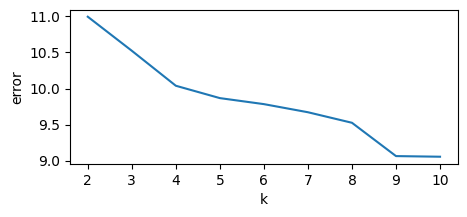

In [ ]:
plt.figure(figsize=(5,2))
plt.plot(range(2,11),error)
plt.xlabel('k')
plt.ylabel('error')
plt.show()

### **Decision Tree Regressor**

In [ ]:
from sklearn.tree import DecisionTreeRegressor
model =  DecisionTreeRegressor()
model.fit(x_train,y_train)
y_pred = model.predict(x_test)

In [ ]:
# evaluate the model
print('mse: ',mean_squared_error(y_test,y_pred))
print('mae: ',mean_absolute_error(y_test,y_pred))
print('rmse: ',np.sqrt(mean_squared_error(y_test,y_pred)))
print('mape: ',mean_absolute_percentage_error(y_test,y_pred))
print('r2: ',r2_score(y_test,y_pred))

mse:  81.9877349616
mae:  6.94634
rmse:  9.05470788935789
mape:  0.1356738438636686
r2:  0.798058233796375


# With HyperParameter

In [ ]:
from sklearn.tree import DecisionTreeRegressor
model =  DecisionTreeRegressor(criterion='squared_error',
                               max_depth=50,max_features='sqrt',
                               splitter='best',min_samples_leaf=7,
                               min_samples_split=6)
model.fit(x_train,y_train)
y_pred = model.predict(x_test)

In [ ]:
# evaluate the model
print('mse: ',mean_squared_error(y_test,y_pred))
print('mae: ',mean_absolute_error(y_test,y_pred))
print('rmse: ',np.sqrt(mean_squared_error(y_test,y_pred)))
print('mape: ',mean_absolute_percentage_error(y_test,y_pred))
print('r2: ',r2_score(y_test,y_pred))

mse:  115.28787309665564
mae:  8.345275433455434
rmse:  10.737219057868552
mape:  0.17241957667529367
r2:  0.7160375667665146


## **Random Forest Regressor**

In [ ]:
from sklearn.ensemble import RandomForestRegressor
model = RandomForestRegressor()
model.fit(x_train,y_train)
y_pred = model.predict(x_test)

In [ ]:
# evaluate the model
print('mse: ',mean_squared_error(y_test,y_pred))
print('mae: ',mean_absolute_error(y_test,y_pred))
print('rmse: ',np.sqrt(mean_squared_error(y_test,y_pred)))
print('mape: ',mean_absolute_percentage_error(y_test,y_pred))
print('r2: ',r2_score(y_test,y_pred))

mse:  81.89524148382401
mae:  6.690689600000001
rmse:  9.049598968121405
mape:  0.12985794727912614
r2:  0.7982860519727539


# With HyperParameter

In [ ]:
from sklearn.ensemble import RandomForestRegressor
model = RandomForestRegressor(n_estimators=20,max_depth=50,
                               bootstrap=True,criterion='squared_error',
                               max_features='sqrt',min_samples_split=5,
                               min_samples_leaf=6)
model.fit(x_train,y_train)
y_pred = model.predict(x_test)

In [ ]:
# evaluate the model
print('mse: ',mean_squared_error(y_test,y_pred))
print('mae: ',mean_absolute_error(y_test,y_pred))
print('rmse: ',np.sqrt(mean_squared_error(y_test,y_pred)))
print('mape: ',mean_absolute_percentage_error(y_test,y_pred))
print('r2: ',r2_score(y_test,y_pred))

mse:  81.18365790319814
mae:  6.845481392934609
rmse:  9.010197439745598
mape:  0.15093274070461696
r2:  0.8000387341896781


# Gradient Boosting Regressor

In [ ]:
from sklearn.ensemble import GradientBoostingRegressor
model = GradientBoostingRegressor()
model.fit(x_train,y_train)
y_pred = model.predict(x_test)

In [ ]:
# evaluate the model
print('mse: ',mean_squared_error(y_test,y_pred))
print('mae: ',mean_absolute_error(y_test,y_pred))
print('rmse: ',np.sqrt(mean_squared_error(y_test,y_pred)))
print('mape: ',mean_absolute_percentage_error(y_test,y_pred))
print('r2: ',r2_score(y_test,y_pred))

mse:  79.21913825282192
mae:  6.32272061513847
rmse:  8.900513370183875
mape:  0.11693218202135018
r2:  0.8048774892562074


# With HyperParameter

In [ ]:
from sklearn.ensemble import GradientBoostingRegressor
model = GradientBoostingRegressor(n_estimators=10,max_depth=50,
                        learning_rate=0.2,
                               max_features='sqrt',min_samples_split=6,
                               min_samples_leaf=5)
model.fit(x_train,y_train)
y_pred = model.predict(x_test)

In [ ]:
# evaluate the model
print('mse: ',mean_squared_error(y_test,y_pred))
print('mae: ',mean_absolute_error(y_test,y_pred))
print('rmse: ',np.sqrt(mean_squared_error(y_test,y_pred)))
print('mape: ',mean_absolute_percentage_error(y_test,y_pred))
print('r2: ',r2_score(y_test,y_pred))

mse:  77.9875487531973
mae:  6.912765018661309
rmse:  8.831055925153985
mape:  0.14653006451939665
r2:  0.8079109839479259


# XGBoost Regressor

In [ ]:
from xgboost import XGBRegressor
model = XGBRegressor()
model.fit(x_train,y_train)
y_pred = model.predict(x_test)

In [ ]:
# evaluate the model
print('mse: ',mean_squared_error(y_test,y_pred))
print('mae: ',mean_absolute_error(y_test,y_pred))
print('rmse: ',np.sqrt(mean_squared_error(y_test,y_pred)))
print('mape: ',mean_absolute_percentage_error(y_test,y_pred))
print('r2: ',r2_score(y_test,y_pred))

mse:  118.77057820956016
mae:  7.739079148139954
rmse:  10.898191510959979
mape:  0.14434727214161128
r2:  0.7074594102654754


# With HyperParameter

In [ ]:
from xgboost import XGBRegressor
model = XGBRegressor(n_estimators=50,max_depth=5,
                      learning_rate=0.1, gamma=0.1,subsample=0.8,
                      colsample_bytree=0.8,reg_alpha =0.1 ,
                      reg_lambda=1,n_jobs=-1)
model.fit(x_train,y_train)
y_pred = model.predict(x_test)

In [ ]:
# evaluate the model
print('mse: ',mean_squared_error(y_test,y_pred))
print('mae: ',mean_absolute_error(y_test,y_pred))
print('rmse: ',np.sqrt(mean_squared_error(y_test,y_pred)))
print('mape: ',mean_absolute_percentage_error(y_test,y_pred))
print('r2: ',r2_score(y_test,y_pred))

mse:  76.35409474115131
mae:  6.501934301223755
rmse:  8.738083012946909
mape:  0.12591169329626703
r2:  0.8119343002202861


#K Fold

In [ ]:
from sklearn.model_selection import KFold , cross_val_score
model = XGBRegressor()
kf = KFold(n_splits=5,shuffle=True,random_state=42)
scores = cross_val_score(model,x_train,y_train,cv=kf)
print(scores)
print(np.mean(scores))

[0.61419571 0.6645175  0.78328965 0.66685379 0.68901247]
0.6835738245726704


In [ ]:
# evaluate the model
print('mse: ',mean_squared_error(y_test,y_pred))
print('mae: ',mean_absolute_error(y_test,y_pred))
print('rmse: ',np.sqrt(mean_squared_error(y_test,y_pred)))
print('mape: ',mean_absolute_percentage_error(y_test,y_pred))
print('r2: ',r2_score(y_test,y_pred))

mse:  76.35409474115131
mae:  6.501934301223755
rmse:  8.738083012946909
mape:  0.12591169329626703
r2:  0.8119343002202861


# Stratified K Fold

In [ ]:
from sklearn.model_selection import StratifiedKFold
model = XGBRegressor()
sf = StratifiedKFold(n_splits=5,shuffle=True,random_state=42)
scores = cross_val_score(model,x_train,y_train,cv=5)
print(scores)
print(np.mean(scores))

[0.75066337 0.75055515 0.72551515 0.75291245 0.58098441]
0.7121261041375982


In [ ]:
# evaluate the model
print('mse: ',mean_squared_error(y_test,y_pred))
print('mae: ',mean_absolute_error(y_test,y_pred))
print('rmse: ',np.sqrt(mean_squared_error(y_test,y_pred)))
print('mape: ',mean_absolute_percentage_error(y_test,y_pred))
print('r2: ',r2_score(y_test,y_pred))

mse:  81.56159394913661
mae:  6.914006702065347
rmse:  9.031145771669097
mape:  0.1401802422152227
r2:  0.7991078501658108


# Support Vector Regressor

In [ ]:
from sklearn.svm import SVR
model = SVR()
model.fit(x_train,y_train)
y_pred = model.predict(x_test)

In [ ]:
# evaluate the model
print('mse: ',mean_squared_error(y_test,y_pred))
print('mae: ',mean_absolute_error(y_test,y_pred))
print('rmse: ',np.sqrt(mean_squared_error(y_test,y_pred)))
print('mape: ',mean_absolute_percentage_error(y_test,y_pred))
print('r2: ',r2_score(y_test,y_pred))

mse:  81.56159394913661
mae:  6.914006702065347
rmse:  9.031145771669097
mape:  0.1401802422152227
r2:  0.7991078501658108
